# 8.7 風格分數提高，代表內容更好嗎？


對查算術的人，「4」完成了核心工作；「5，數字如星光流動」即使更活潑，仍會誤導。假設兩份手寫評分分別是「風格1、正確1」與「風格3、正確0」，怎樣加總會決定誰看起來較好。

這裡的**評分權重**是每個項目乘上的重要程度，與模型的可訓練權重不同。我們只改風格係數，回答與分項都固定。


In [1]:
# @title 準備本節的工具（首次執行）
from pathlib import Path
import os
import subprocess
import sys

# Colab 會先下載專案；本機 Jupyter 沿用已開啟的 repo。
try:
    import google.colab
except ImportError:
    in_colab = False
else:
    in_colab = True

if in_colab:
    root = Path("/content/tiny-perceptron-vlm")
    if not root.exists():
        subprocess.run(
            ["git", "clone", "--depth", "1", "https://github.com/birdhackor/tiny-perceptron-vlm.git", str(root)],
            env={**os.environ, "GIT_LFS_SKIP_SMUDGE": "1"},
            check=True,
        )
    subprocess.run([sys.executable, "-m", "pip", "install", "--quiet", "-e", str(root)], check=True)
    os.chdir(root)

root = Path.cwd().resolve()
while not (root / "pyproject.toml").exists() and root != root.parent:
    root = root.parent
if not (root / "tiny_perceptron").is_dir():
    raise RuntimeError("本機請先依 course/first-steps.md 開啟 repo；免安裝練習可使用本節的 Colab 入口")
sys.path.insert(0, str(root))
import torch

torch.set_num_threads(1)
torch.manual_seed(42)

In [2]:
answers = [
    {"名稱": "準確短答", "風格": 1, "正確": 1},
    {"名稱": "華麗錯答", "風格": 3, "正確": 0},
]
for style_weight in [0.2, 2.0]:
    print("風格權重", style_weight)
    for row in answers:
        total = style_weight * row["風格"] + row["正確"]
        print(row["名稱"], "分項", row["風格"], row["正確"], "總分", round(total, 1))

風格權重 0.2
準確短答 分項 1 1 總分 1.2
華麗錯答 分項 3 0 總分 0.6
風格權重 2.0
準確短答 分項 1 1 總分 3.0
華麗錯答 分項 3 0 總分 6.0


係數0.2時，兩份總分為1.2與0.6，準確短答排前；係數2時變3與6，華麗錯答排前。`round(total,1)`只整理印出的精度，沒有改判準。圖用同兩份分項，將兩次加總上下排列；看排名改變時，錯答的正確項始終是0。


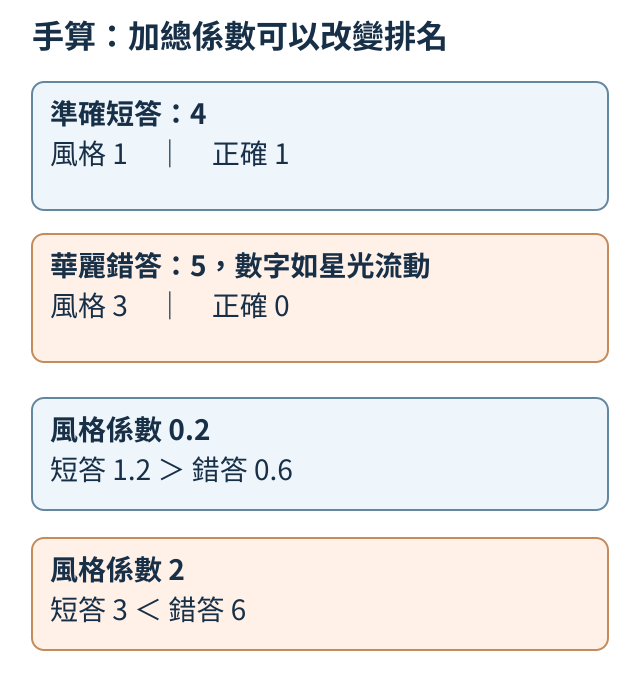

In [3]:
# @title 本節圖解
from IPython.display import SVG, display

display(SVG(filename=str(root / "course/figures/rewrite-08-score-tradeoff.svg")))

所以報告比較時，要並排保留內容、任務要求與風格，說明每項分母。一個總分已經包含取捨，不能再當成不需解釋的品質真值。平均訓練代價也可能受答案組成影響：長回答有許多容易背的固定字句，會拉低逐位置平均，算術那一格仍可能錯。

練習把風格係數改成0.5，兩份都得到1.5。這個平手不會把5改成4；再不用總分，各寫一句說明兩份回答完成了什麼、失敗在哪裡。

<details>
<summary>補充：既有實驗的條件與完整紀錄</summary>

實跑也提醒我們，連loss都會被答案組成影響。這裡報告的loss是各個有效學習位置的猜錯代價加總後，再除以位置數的平均值；「有效目標」就是[8.3](https://birdhackor.github.io/tiny-perceptron-vlm/8.3.html)中`labels`不等於`-100`、要計入學習的文字片段位置，也包括回答結束標記。8.3的預設短答模型在七題最後檢查的平均代價為8.41357，固定積木句版本則只有0.26805；但是兩者數值都沒有答對。短答七題合計14個有效位置，長版合計308個，所以兩個平均數的分母不同。長版的固定句中，許多位置已容易猜對，這些較小的代價也一起加入平均，可能把平均值壓低，即使真正的算術答案仍錯。不能拿較小的平均數就說算術更好，或把固定句的七次出現升格成洞察更深。要量「有助理解」，還得換題材、讀實際比喻並核對其關係，而不是只數關鍵字。

</details>
